In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(42)

In [2]:
normal_salaries = np.random.normal(loc=50000, scale=15000, size=1000)

anamolies = np.random.uniform(low=200000, high=300000, size=10)
anamolies = np.append(anamolies, np.random.uniform(low=10000, high=20000, size=10))

salaries = np.concatenate([normal_salaries, anamolies])

In [3]:
df = pd.DataFrame({'salary':salaries})
df.head()

,salary
0,57450.712295
1,47926.035482
2,59715.328072
3,72845.447846
4,46487.699379


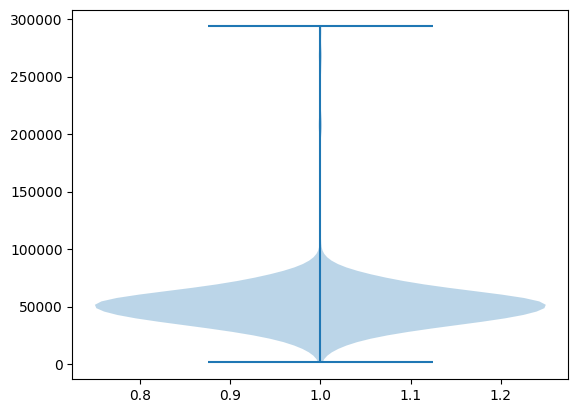

In [6]:
plt.violinplot(df["salary"])
plt.show()


In [10]:
model = IsolationForest(n_estimators=100, max_samples='auto',contamination=0.1, max_features=1.0)
model.fit(df[['salary']])

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [11]:
df['anamoly'] = model.predict(df[['salary']])
df['anamoly'] = df['anamoly'].apply(lambda x: 'Anamoly' if x == -1 else 'Normal')

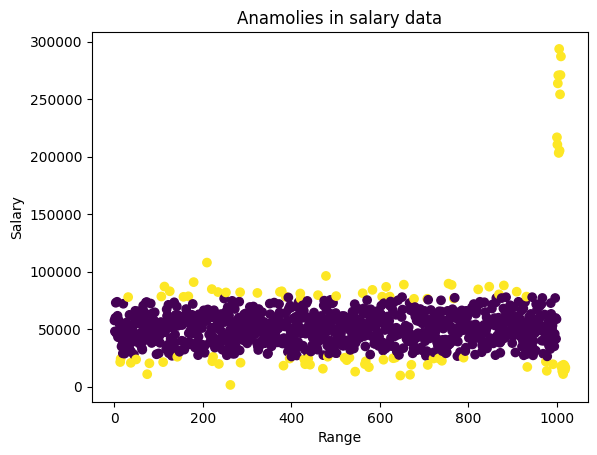

In [17]:
plt.scatter(x=range(len(df)), y=df['salary'], c=(df['anamoly']=='Anamoly').astype(int))
plt.title("Anamolies in salary data")
plt.xlabel("Range")
plt.ylabel("Salary")
# plt.legend()
plt.show()